In [82]:
# Importamos la librería principal para análisis de datos
import pandas as pd

# Cargamos el archivo parquet seleccionando solo las columnas requeridas (ahorro de memoria)
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "region", "comuna", "sexo", "edad",
        "p27_nacionalidad", "p27_nacionalidad_rec",
        "escolaridad", "sit_fuerza_trabajo"
    ],
)

In [66]:
persona.shape

(18480432, 8)

In [85]:
# Desplegamos las primeras 10 filas para visualizar la estructura y valores de los datos
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [86]:
# Verificamos el tipo de dato de cada columna para validar la consistencia de la información
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

In [87]:
# Filtramos la base nacional dejando solo los registros donde la variable "region" sea igual a 13
my_region = persona[persona["region"] == 13]

# Imprimimos el número de filas resultantes con formato de separador de miles para facilitar la lectura
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


In [88]:
# Calculamos la proporción de cada categoría en la columna de nacionalidad
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)

# OJO: Cambiamos 'Extranjero' por 2 (suponiendo que 2 es el código para extranjero en el diccionario del Censo). 
# Si el código es otro, solo cambia el 2 por el número correcto.
print(f"% foreign-born: {foreign.get(2, 0):.1%}")

% foreign-born: 12.2%


In [89]:
# Cargamos la base de datos de salud, definiendo el delimitador y la codificación
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";", 
    encoding="utf-8-sig",
    low_memory=False # Evita el warning de tipos de datos mixtos
)

# Imprimimos la cantidad total de registros con separador de miles
print(f"Total rows: {len(eno):,}")

# Desplegamos la lista completa de columnas para identificar las variables de interés
print(eno.columns.tolist())

Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [90]:
# Filtramos la base ENO para obtener solo los registros de la Región Metropolitana
eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]

# Verificamos la cantidad de registros filtrados para nuestra zona
print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 126,669


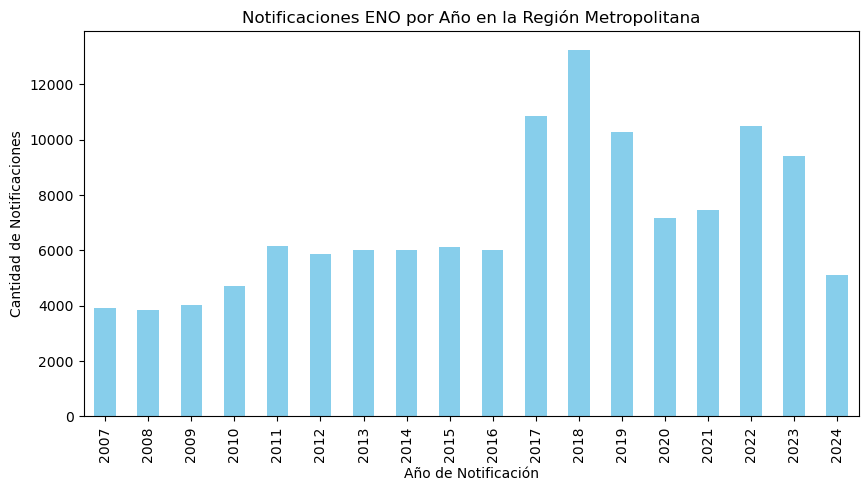

In [ ]:
# Importamos la librería para generación de gráficos (si no se importó antes)
import matplotlib.pyplot as plt

# Contamos las notificaciones por año y las ordenamos por el índice (año) 
notificaciones_ano = eno_region["anho_notificacion"].value_counts().sort_index()

# Generamos un gráfico de barras para visualizar la distribución anual 
notificaciones_ano.plot(kind="bar", figsize=(10, 5), color="skyblue")

# Personalizamos el gráfico con títulos y etiquetas claras para los ejes
plt.title("Notificaciones ENO por Año en la Región Metropolitana")
plt.xlabel("Año de Notificación")
plt.ylabel("Cantidad de Notificaciones")

# Mostramos el gráfico en el notebook
plt.show()

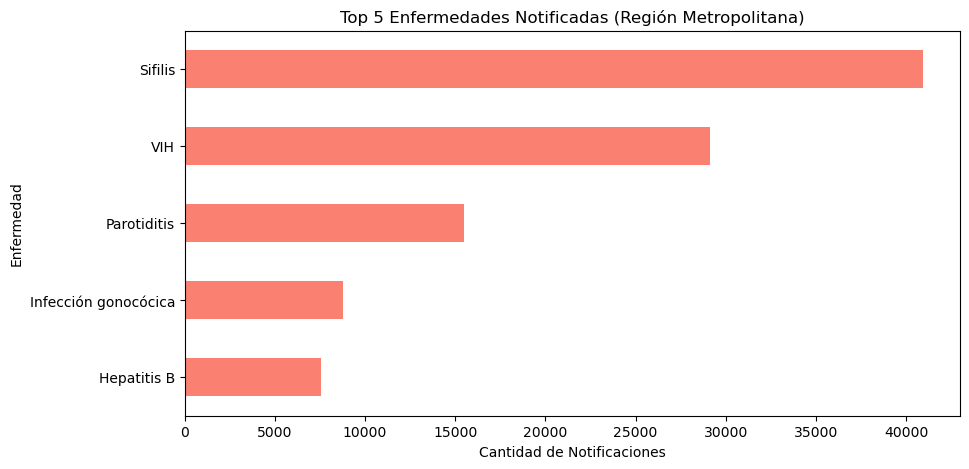

In [ ]:
# Contamos la frecuencia de cada enfermedad y extraemos las 5 más comunes 
top_eno = eno_region["ENO"].value_counts().head(5)

# Ordenamos los valores de menor a mayor antes de graficar 
# Esto asegura que en el gráfico horizontal (barh), la enfermedad con más casos quede arriba
top_eno.sort_values().plot(kind="barh", figsize=(10, 5), color="salmon")

# Personalizamos la visualización con títulos y etiquetas descriptivas 
plt.title("Top 5 Enfermedades Notificadas (Región Metropolitana)")
plt.xlabel("Cantidad de Notificaciones")
plt.ylabel("Enfermedad")

# Desplegamos el gráfico 
plt.show()

In [75]:
#Show the distribution of nacionalidad in your region’s ENO data using
#.value_counts(). Note: you will likely see a "Desconocido" (unknown)
#category — report it, but do not drop it silently.

In [93]:
# Importamos la librería para manejar archivos comprimidos
import zipfile

# Definimos la lista de columnas específicas que requerimos (optimización de memoria)
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

# Abrimos el archivo ZIP y luego el archivo de texto interno sin descomprimirlo físicamente
with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        # Cargamos los datos especificando el separador '|' y la codificación adecuada
        grd = pd.read_csv(f, sep="|", usecols=cols,
                          encoding="latin-1",
                          low_memory=False)

# Imprimimos el total de egresos hospitalarios cargados con formato de miles
print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


In [94]:
# Definimos la lista de todas las comunas de la Región Metropolitana en MAYÚSCULAS
my_comunas = [
    "SANTIAGO", "CERRILLOS", "CERRO NAVIA", "CONCHALÍ", "EL BOSQUE", 
    "ESTACIÓN CENTRAL", "HUECHURABA", "INDEPENDENCIA", "LA CISTERNA", 
    "LA FLORIDA", "LA GRANJA", "LA PINTANA", "LA REINA", "LAS CONDES", 
    "LO BARNECHEA", "LO ESPEJO", "LO PRADO", "MACUL", "MAIPÚ", 
    "ÑUÑOA", "PEDRO AGUIRRE CERDA", "PEÑALOLÉN", "PROVIDENCIA", 
    "PUDAHUEL", "QUILICURA", "QUINTA NORMAL", "RECOLETA", "RENCA", 
    "SAN JOAQUÍN", "SAN MIGUEL", "SAN RAMÓN", "VITACURA", 
    "PUENTE ALTO", "PIRQUE", "SAN JOSÉ DE MAIPO", "COLINA", 
    "LAMPA", "TILTIL", "SAN BERNARDO", "BUIN", "PAINE", 
    "CALERA DE TANGO", "MELIPILLA", "ALHUÉ", "CURACAVÍ", 
    "MARÍA PINTO", "SAN PEDRO", "TALAGANTE", "EL MONTE", 
    "ISLA DE MAIPO", "PADRE HURTADO", "PEÑAFLOR"
]

# Filtramos los datos de GRD para que solo incluyan las comunas de la lista
grd_region = grd[grd["COMUNA"].isin(my_comunas)]

# Imprimimos la cantidad de egresos resultantes para la región
print(f"Discharges in my region: {len(grd_region):,}")

Discharges in my region: 332,717


In [ ]:
# Cargamos la tabla de referencia CIE-10 desde el archivo Excel [cite: 137, 138]
cie10 = pd.read_excel("CIE-10.xlsx", sheet_name="CIE 10")

# Realizamos el cruce (merge) para añadir descripciones legibles a los diagnósticos 
grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]], # Seleccionamos solo las columnas útiles 
    left_on="DIAGNOSTICO1",                        # Columna clave en la tabla de egresos 
    right_on="Código",                             # Columna clave en la tabla CIE-10 
    how="left"                                     # Mantenemos todos los registros de la izquierda 
)

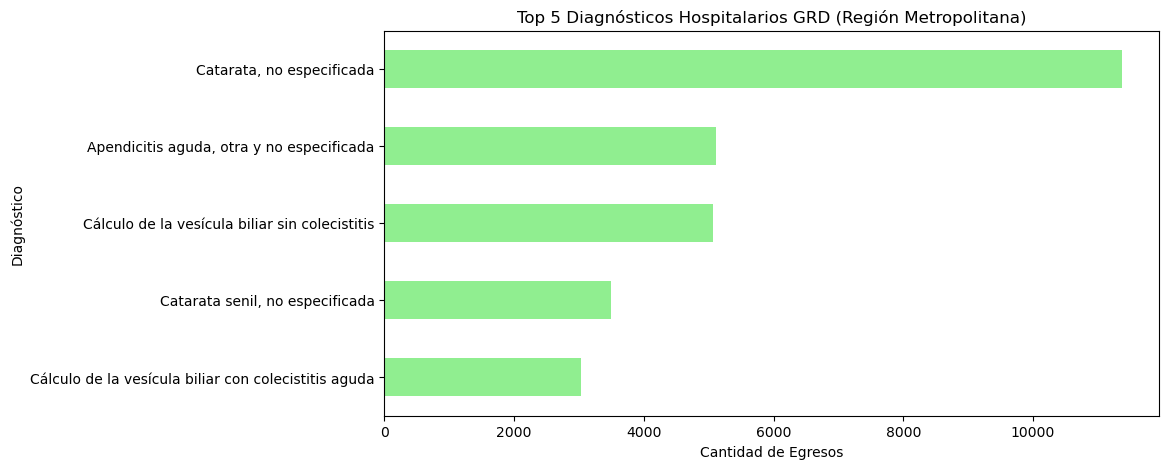

In [96]:
# Calculamos la frecuencia de los diagnósticos utilizando la descripción textual
top_diagnosticos = grd_region["Descripción"].value_counts().head(5)

# Graficamos los resultados en un gráfico de barras horizontal
# Usamos sort_values() para que la barra más larga (mayor frecuencia) aparezca en la parte superior
top_diagnosticos.sort_values().plot(kind="barh", figsize=(10, 5), color="lightgreen")

# Añadimos títulos y etiquetas para una correcta interpretación
plt.title("Top 5 Diagnósticos Hospitalarios GRD (Región Metropolitana)")
plt.xlabel("Cantidad de Egresos")
plt.ylabel("Diagnóstico")

# Mostramos la figura final
plt.show()